# Fish - riepilogo generale

Notebook aggregato per confrontare il macro-F1 su tutti gli stride e visualizzare i tempi di esecuzione usando i CSV gia' prodotti dai notebook dei singoli classificatori.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start_path: Path = Path.cwd()) -> Path:
    current = start_path.resolve()
    while current != current.parent:
        if (current / "pyproject.toml").exists() and (current / "scripts").exists():
            return current
        current = current.parent
    raise RuntimeError("Repository root not found")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

RESULTS_DIR = REPO_ROOT / "results" / "Fish"
PLOTS_DIR = REPO_ROOT / "plots" / "Fish" / "overall"
TABLES_DIR = REPO_ROOT / "results" / "Fish" / "overall"

REPO_ROOT

PosixPath('/Users/gabbo/Documents/GitHub/Thesis_SlidingWindow')

In [2]:
from scripts.plot_fish_overall import build_overall_plots

outputs = build_overall_plots(
    results_dir=RESULTS_DIR,
    plots_dir=PLOTS_DIR,
    tables_dir=TABLES_DIR,
)

print("Saved plots:")
for path in outputs["plots"]:
    print(path.relative_to(REPO_ROOT))

print("\nSaved tables:")
for path in outputs["tables"]:
    print(path.relative_to(REPO_ROOT))

Saved plots:
plots/Fish/overall/overall_macro_f1_by_stride.png
plots/Fish/overall/overall_phase_total_times_hours.png
plots/Fish/overall/overall_per_configuration_time_histograms.png
plots/Fish/overall/overall_tuning_trial_time_histograms.png

Saved tables:
results/Fish/overall/overall_macro_f1_all_points.csv
results/Fish/overall/overall_macro_f1_best_by_stride.csv
results/Fish/overall/overall_phase_total_times.csv
results/Fish/overall/overall_tuning_trial_time_summary.csv
results/Fish/overall/overall_selected_comparison_dirs.csv


## Macro-F1 per stride

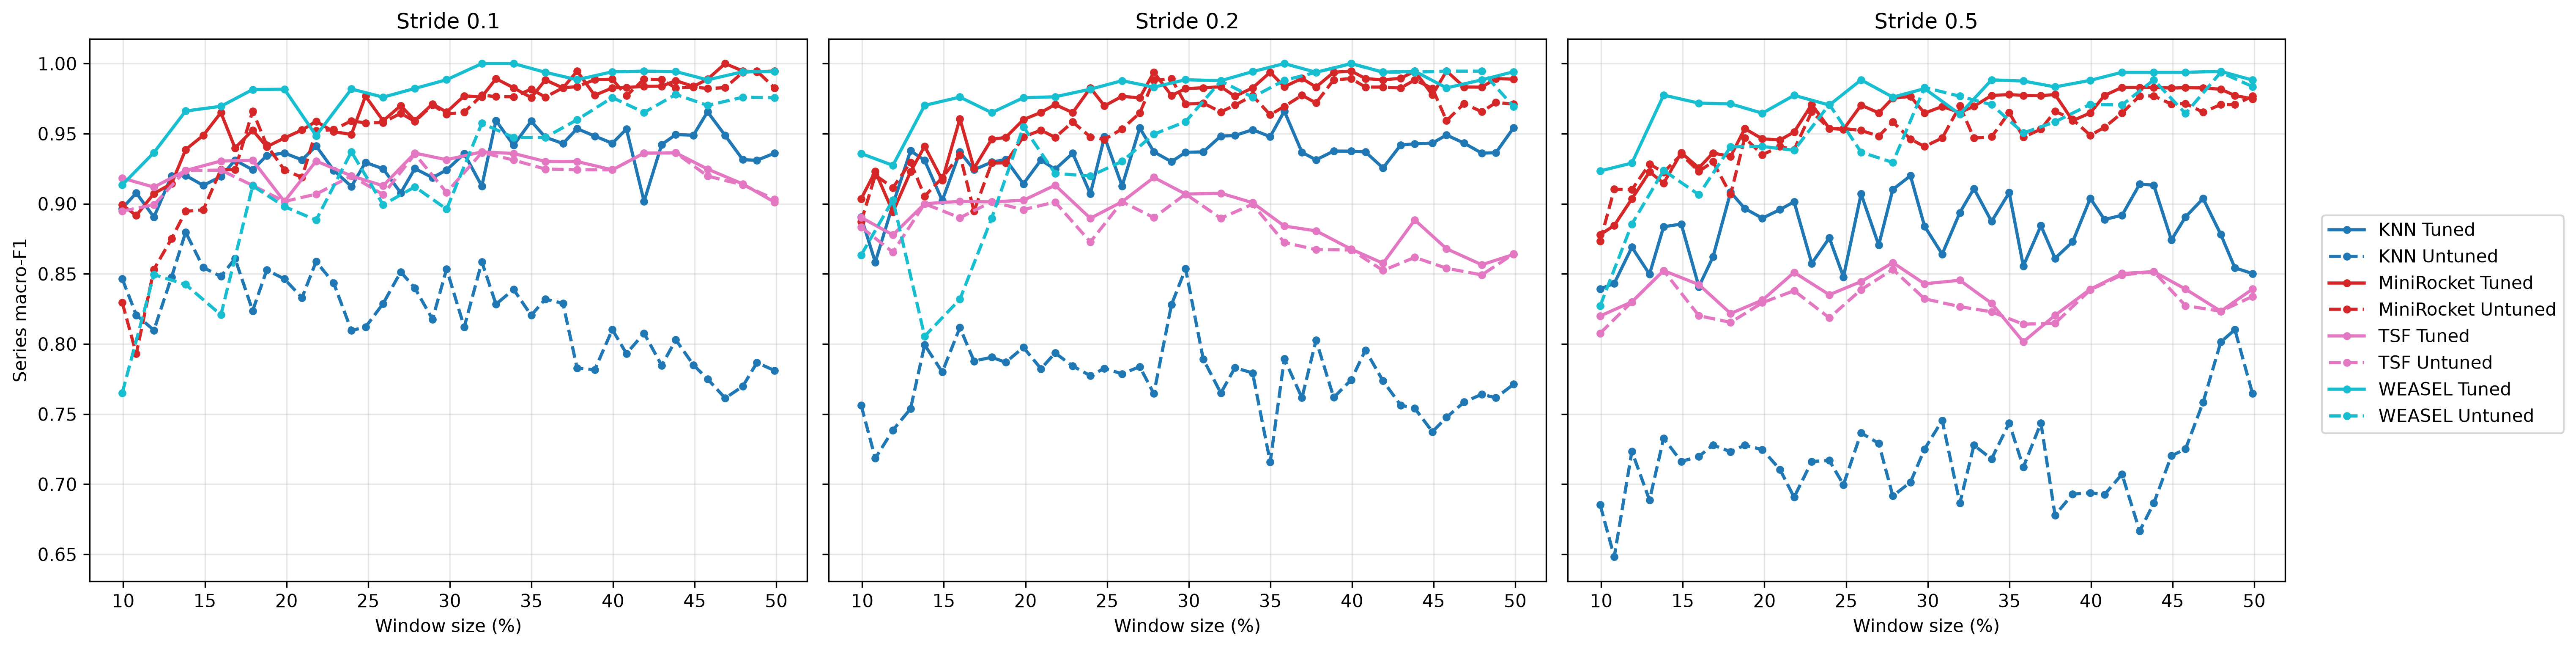

In [3]:
from IPython.display import Image, display

display(Image(filename=str(PLOTS_DIR / "overall_macro_f1_by_stride.png")))

## Tempi

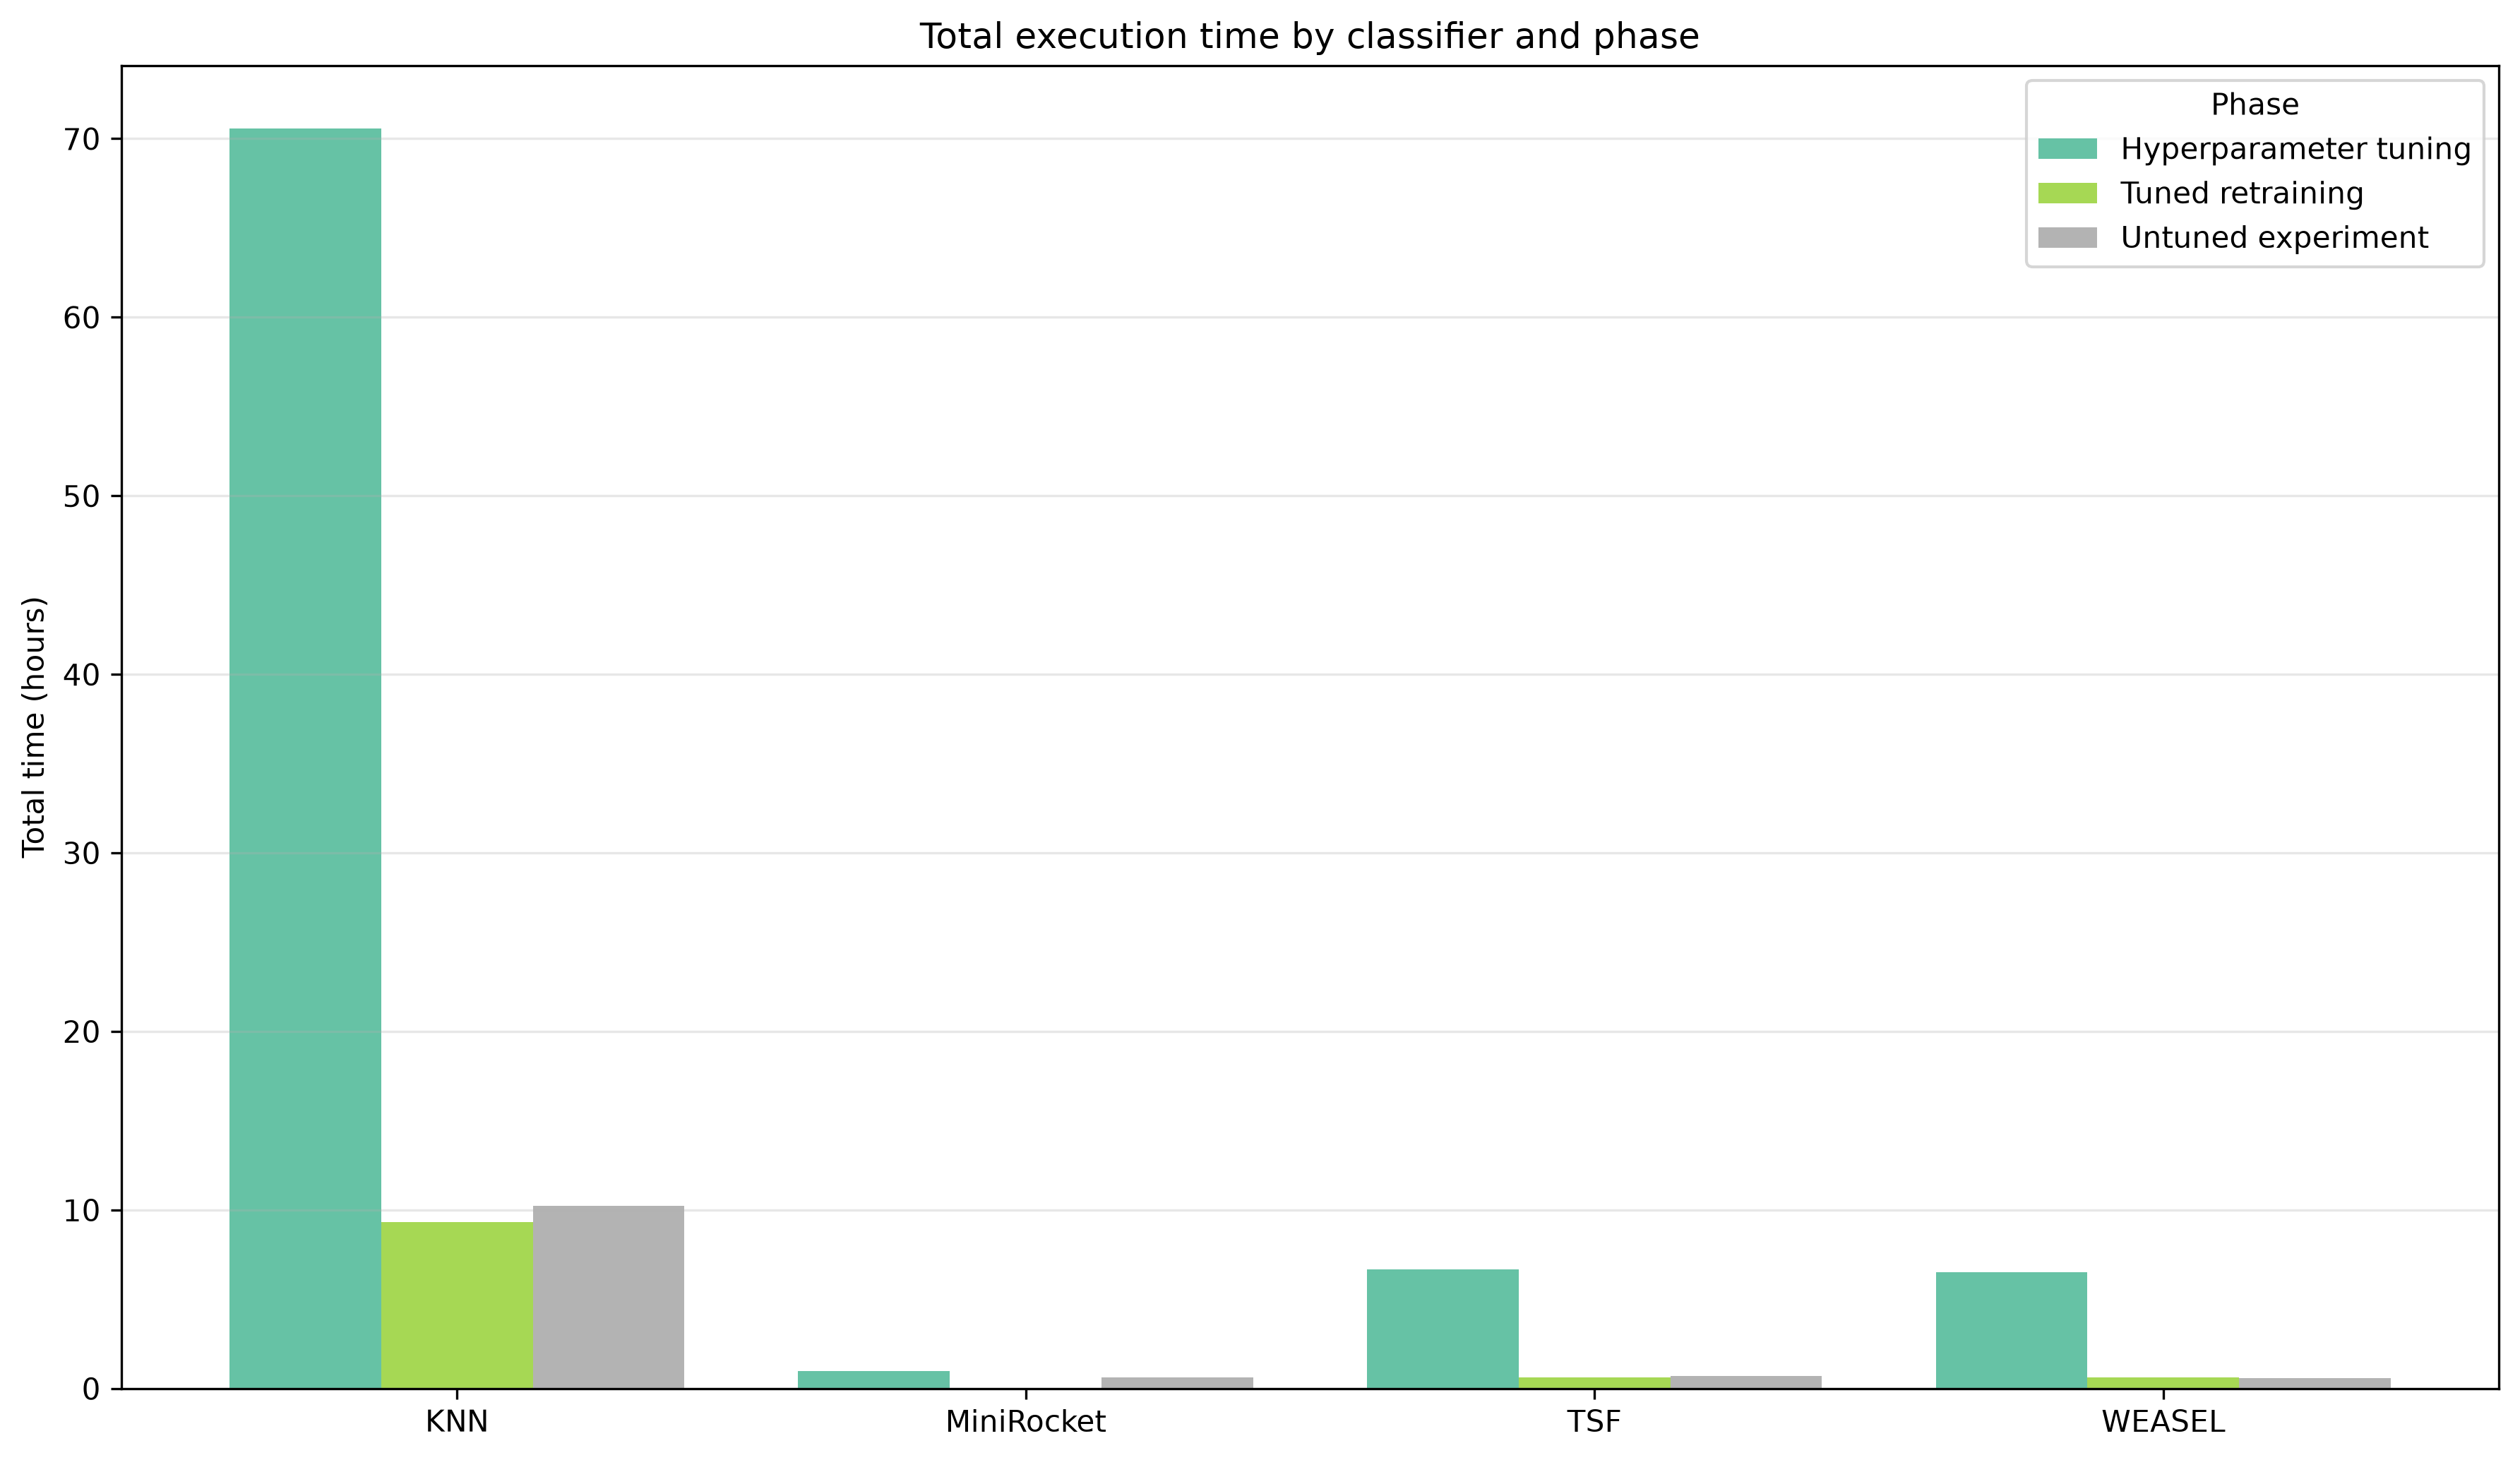

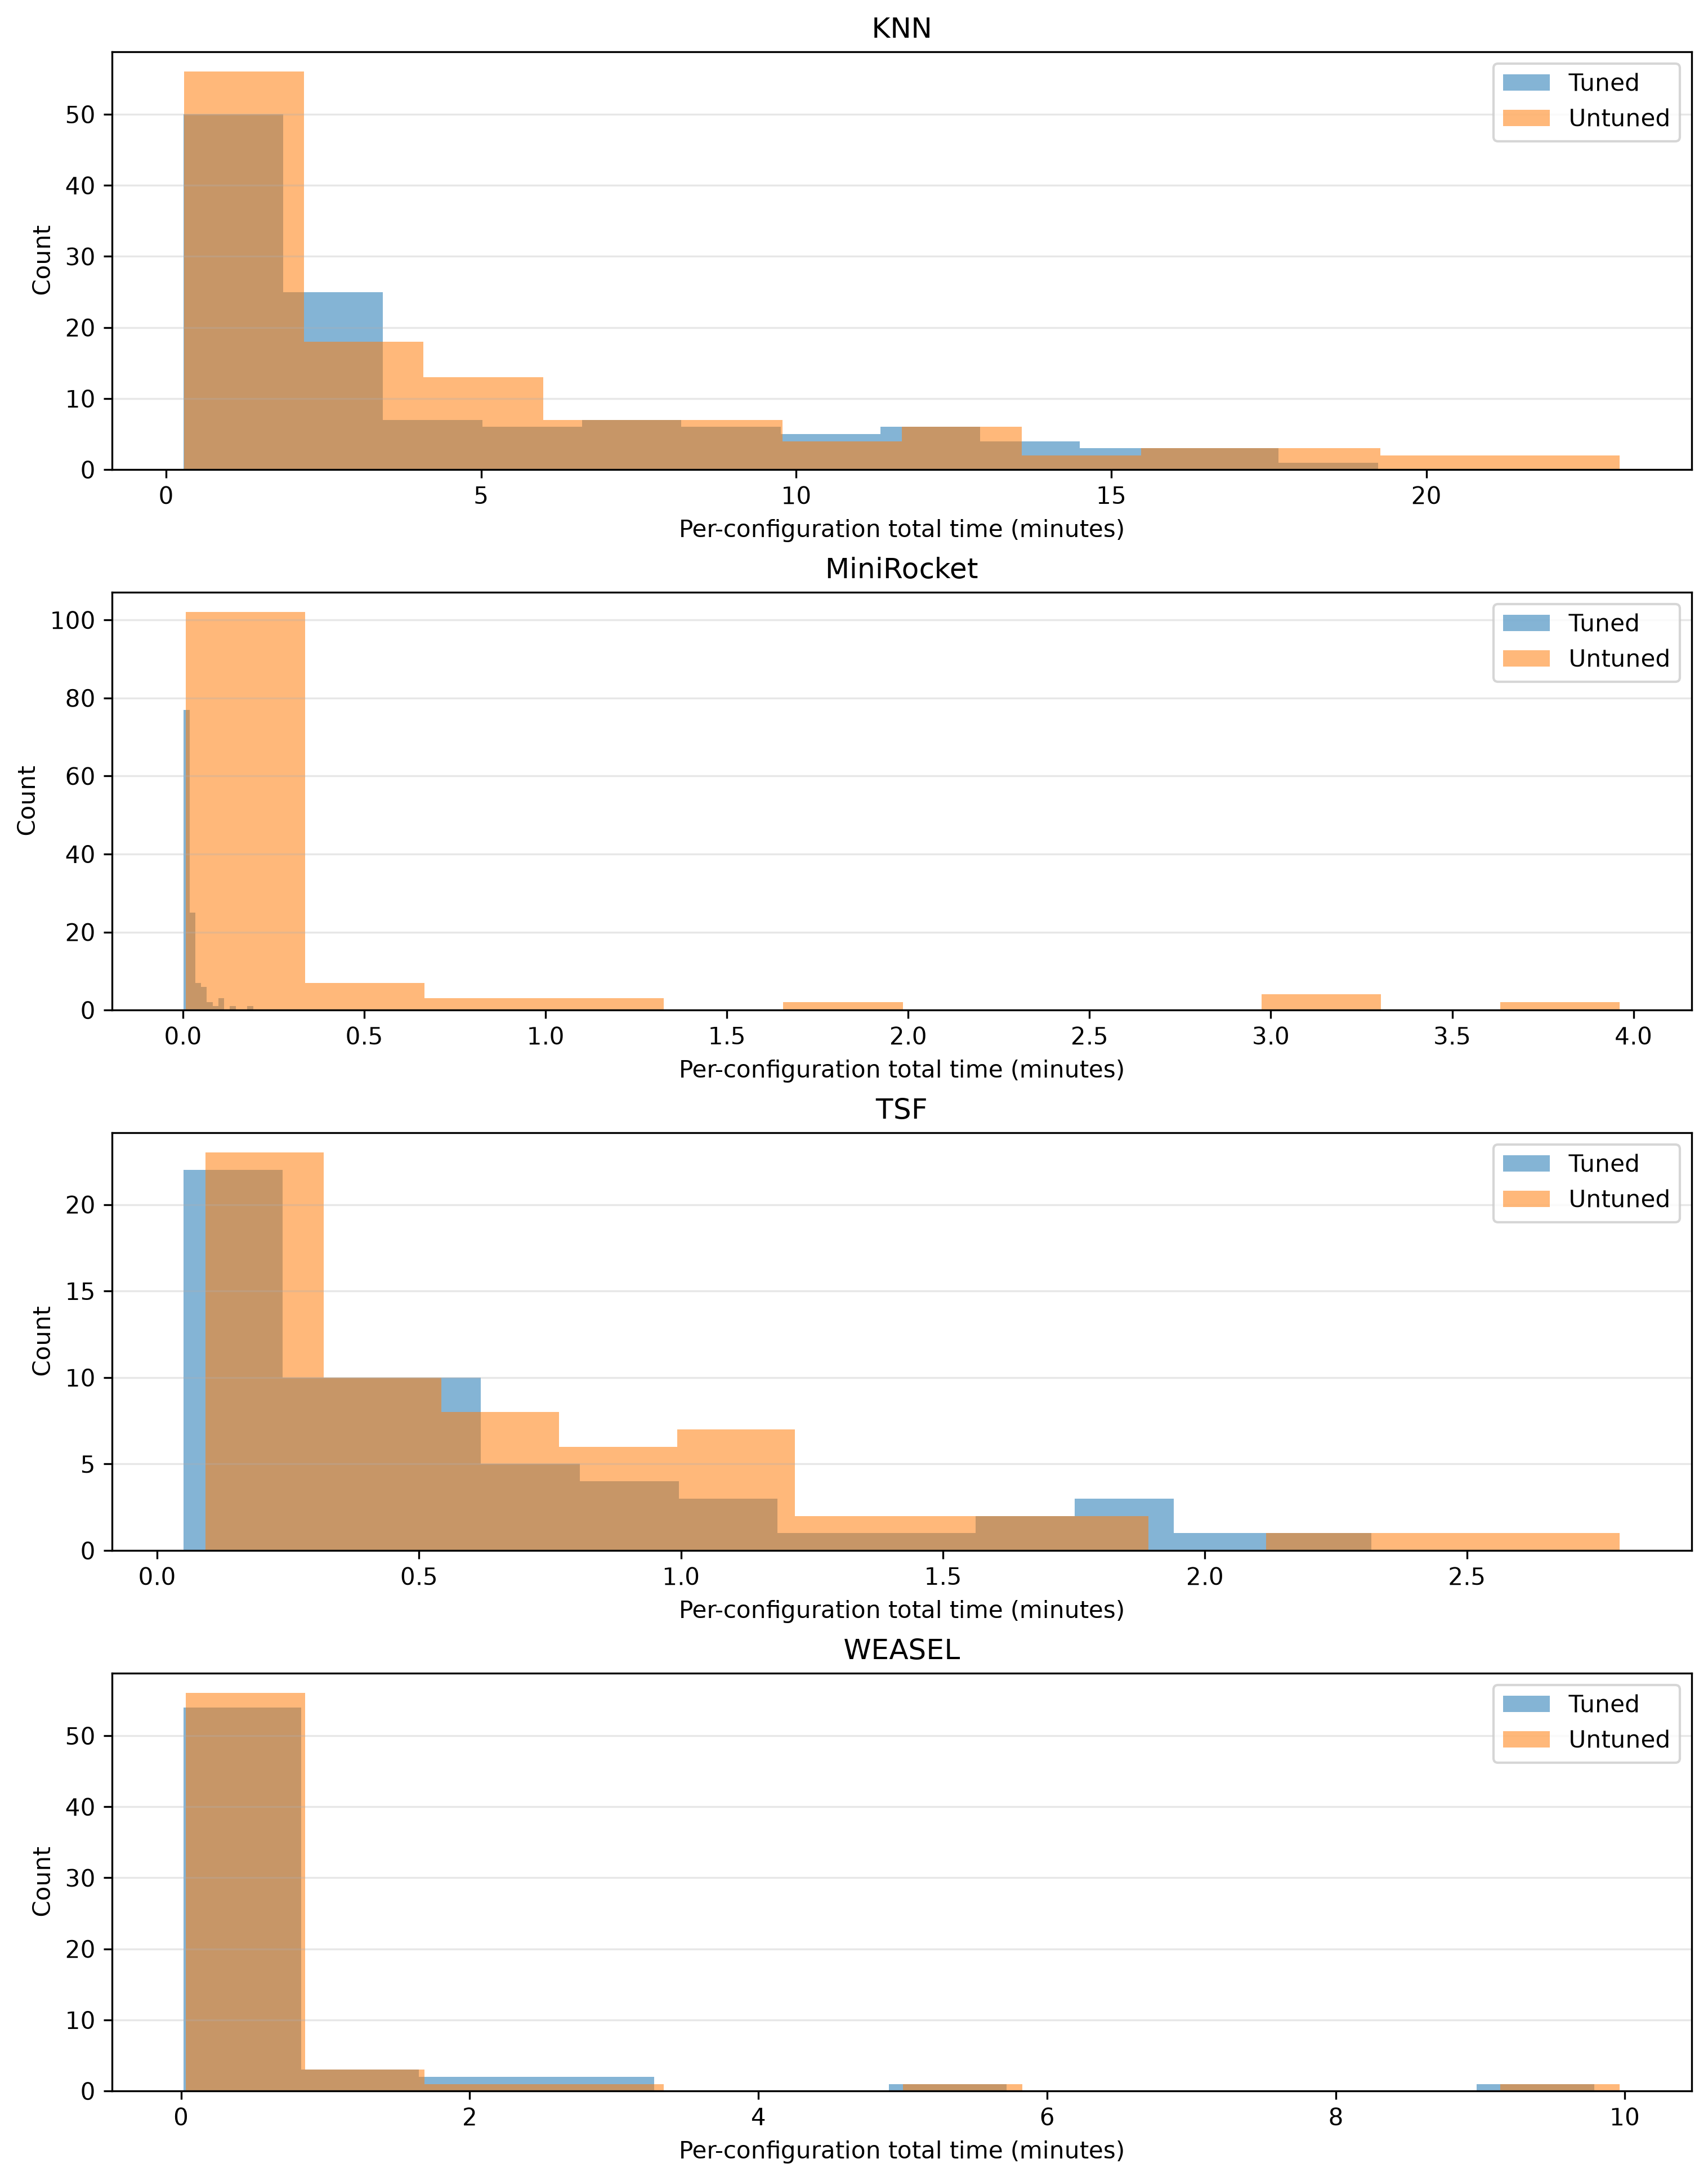

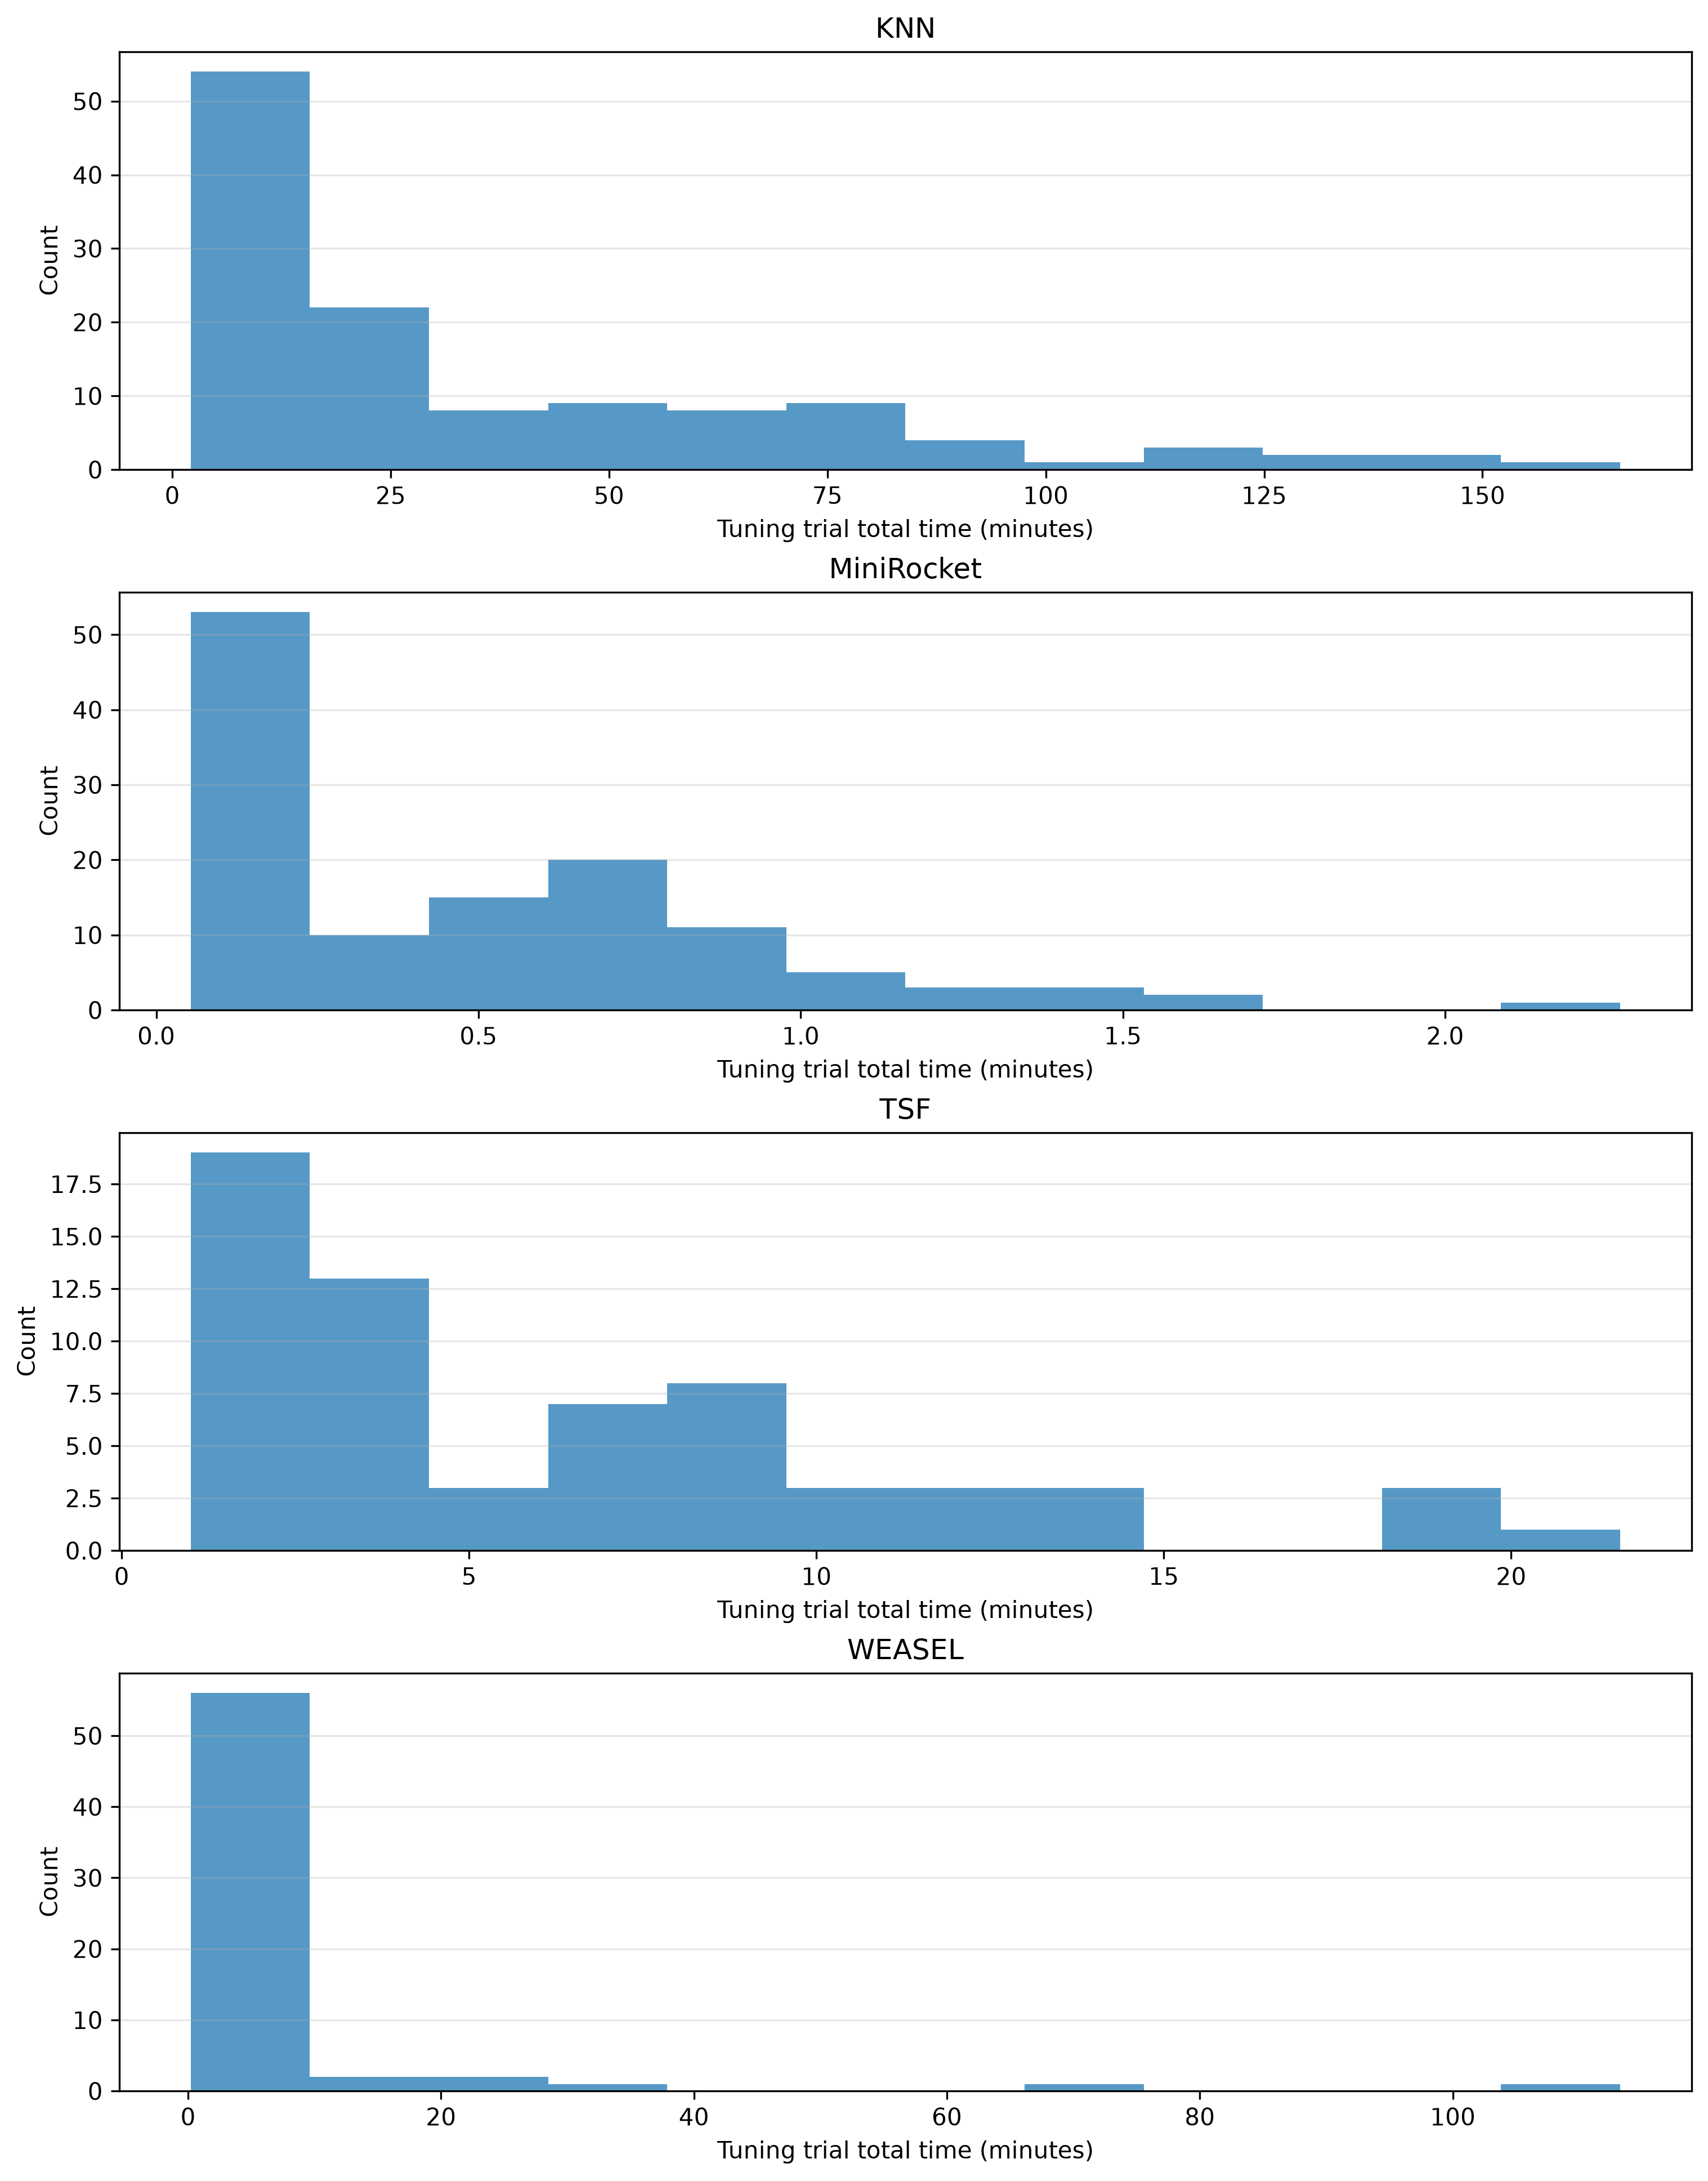

In [4]:
for name in [
    "overall_phase_total_times_hours.png",
    "overall_per_configuration_time_histograms.png",
    "overall_tuning_trial_time_histograms.png",
]:
    display(Image(filename=str(PLOTS_DIR / name)))

## Tabelle riepilogative

In [5]:
import pandas as pd

selected_dirs = pd.read_csv(TABLES_DIR / "overall_selected_comparison_dirs.csv")
best_by_stride = pd.read_csv(TABLES_DIR / "overall_macro_f1_best_by_stride.csv")
time_summary = pd.read_csv(TABLES_DIR / "overall_tuning_trial_time_summary.csv")

display(selected_dirs)
display(best_by_stride)
display(time_summary)

,classifier_dir,comparison_dir
0,KNeighborsTimeSeriesClassifier,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
1,MiniRocket,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
2,TimeSeriesForestClassifier,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...
3,WEASEL,/Users/gabbo/Documents/GitHub/Thesis_SlidingWi...


,dataset,classifier,classifier_label,run_type,window_size,window_percentage,stride_ratio,series_macro_f1,fit_time_sec,predict_time_sec,total_time_sec
0,Fish,KNeighborsTimeSeriesClassifier,KNN,Tuned,212,0.457883,0.1,0.965595,0.001511,336.078524,336.096254
1,Fish,KNeighborsTimeSeriesClassifier,KNN,Untuned,64,0.138229,0.1,0.879768,0.004120,1134.501811,1134.537786
2,Fish,KNeighborsTimeSeriesClassifier,KNN,Tuned,166,0.358531,0.2,0.966098,0.001095,142.796879,142.835381
3,Fish,KNeighborsTimeSeriesClassifier,KNN,Untuned,138,0.298056,0.2,0.853702,0.001291,171.036169,171.056074
4,Fish,KNeighborsTimeSeriesClassifier,KNN,Tuned,134,0.289417,0.5,0.919979,0.000644,23.286833,23.303236
5,Fish,KNeighborsTimeSeriesClassifier,KNN,Untuned,226,0.488121,0.5,0.810226,0.000610,24.352303,24.368894
6,Fish,MiniRocketClassifier,MiniRocket,Tuned,217,0.468683,0.1,1.000000,0.949408,0.231409,1.198231
7,Fish,MiniRocketClassifier,MiniRocket,Untuned,226,0.488121,0.1,0.994693,1.443656,0.778430,2.238343
8,Fish,MiniRocketClassifier,MiniRocket,Tuned,212,0.457883,0.2,0.994693,0.243793,0.122904,0.382742
9,Fish,MiniRocketClassifier,MiniRocket,Untuned,185,0.399568,0.2,0.989294,0.767570,0.461192,1.244532


,classifier_label,n_configurations,total_tuning_time_min,mean_trial_time_min,median_trial_time_min
0,KNN,123,4233.781378,34.420987,19.158003
1,MiniRocket,123,59.615490,0.484679,0.396669
2,TSF,63,401.254612,6.369121,4.409662
3,WEASEL,63,391.114907,6.208173,1.292044
